In [1]:
!pip install -q kagglehub transformers datasets sentencepiece \
             rouge-score nltk gensim networkx spacy \
             sentence-transformers accelerate torch

!python -m spacy download en_core_web_sm -q

print("Installation done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.4 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Installation done!


In [2]:
import kagglehub, os, re, warnings, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import networkx as nx
from collections  import Counter
warnings.filterwarnings('ignore')

# ── NLTK ─────────────────────────────────────────────────────
import nltk
for pkg in ['punkt','stopwords','wordnet',
            'averaged_perceptron_tagger','punkt_tab']:
    nltk.download(pkg, quiet=True)

from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize

# ── spaCy ────────────────────────────────────────────────────
import spacy
nlp_spacy = spacy.load('en_core_web_sm')

# ── Sklearn ───────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import cosine_similarity

# ── Transformers ─────────────────────────────────────────────
import torch
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    BartTokenizer, BartForConditionalGeneration,
    T5Tokenizer,   T5ForConditionalGeneration,
    PegasusTokenizer, PegasusForConditionalGeneration,
    BertTokenizer,    BertModel,
    pipeline
)

# ── ROUGE ─────────────────────────────────────────────────────
from rouge_score import rouge_scorer

# ── Sentence Transformers ─────────────────────────────────────
from sentence_transformers import SentenceTransformer

STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

print("All imports done!")
print(f"   PyTorch    : {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Device     : {device}")

All imports done!
   PyTorch    : 2.10.0+cu128
   Device     : cuda


In [3]:
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print("Path:", path)

for root, _, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

Path: /kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [4]:
csv_path = os.path.join(path, "Reviews.csv")
df_raw   = pd.read_csv(csv_path, nrows=5000)

print("Shape  :", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head(3)

Shape  : (5000, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [5]:
# Use Text as document and Summary as reference summary
df = df_raw[['Text','Summary']].copy()
df.dropna(subset=['Text','Summary'], inplace=True)
df.drop_duplicates(subset=['Text'],  inplace=True)
df.reset_index(drop=True, inplace=True)

# Filter reasonable length docs
df['text_len']    = df['Text'].apply(lambda x: len(str(x).split()))
df['summary_len'] = df['Summary'].apply(lambda x: len(str(x).split()))

df = df[(df['text_len']    >= 30)  &
        (df['text_len']    <= 500) &
        (df['summary_len'] >= 3)   &
        (df['summary_len'] <= 50)]
df.reset_index(drop=True, inplace=True)

print(f"Final dataset shape : {df.shape}")
print(f"Avg document words  : {df['text_len'].mean():.1f}")
print(f"Avg summary words   : {df['summary_len'].mean():.1f}")
df.head(3)

Final dataset shape : (2821, 4)
Avg document words  : 91.3
Avg summary words   : 5.3


,Text,Summary,text_len,summary_len
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,48,4
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,31,3
2,This is a confection that has been around a fe...,"""Delight"" says it all",94,4


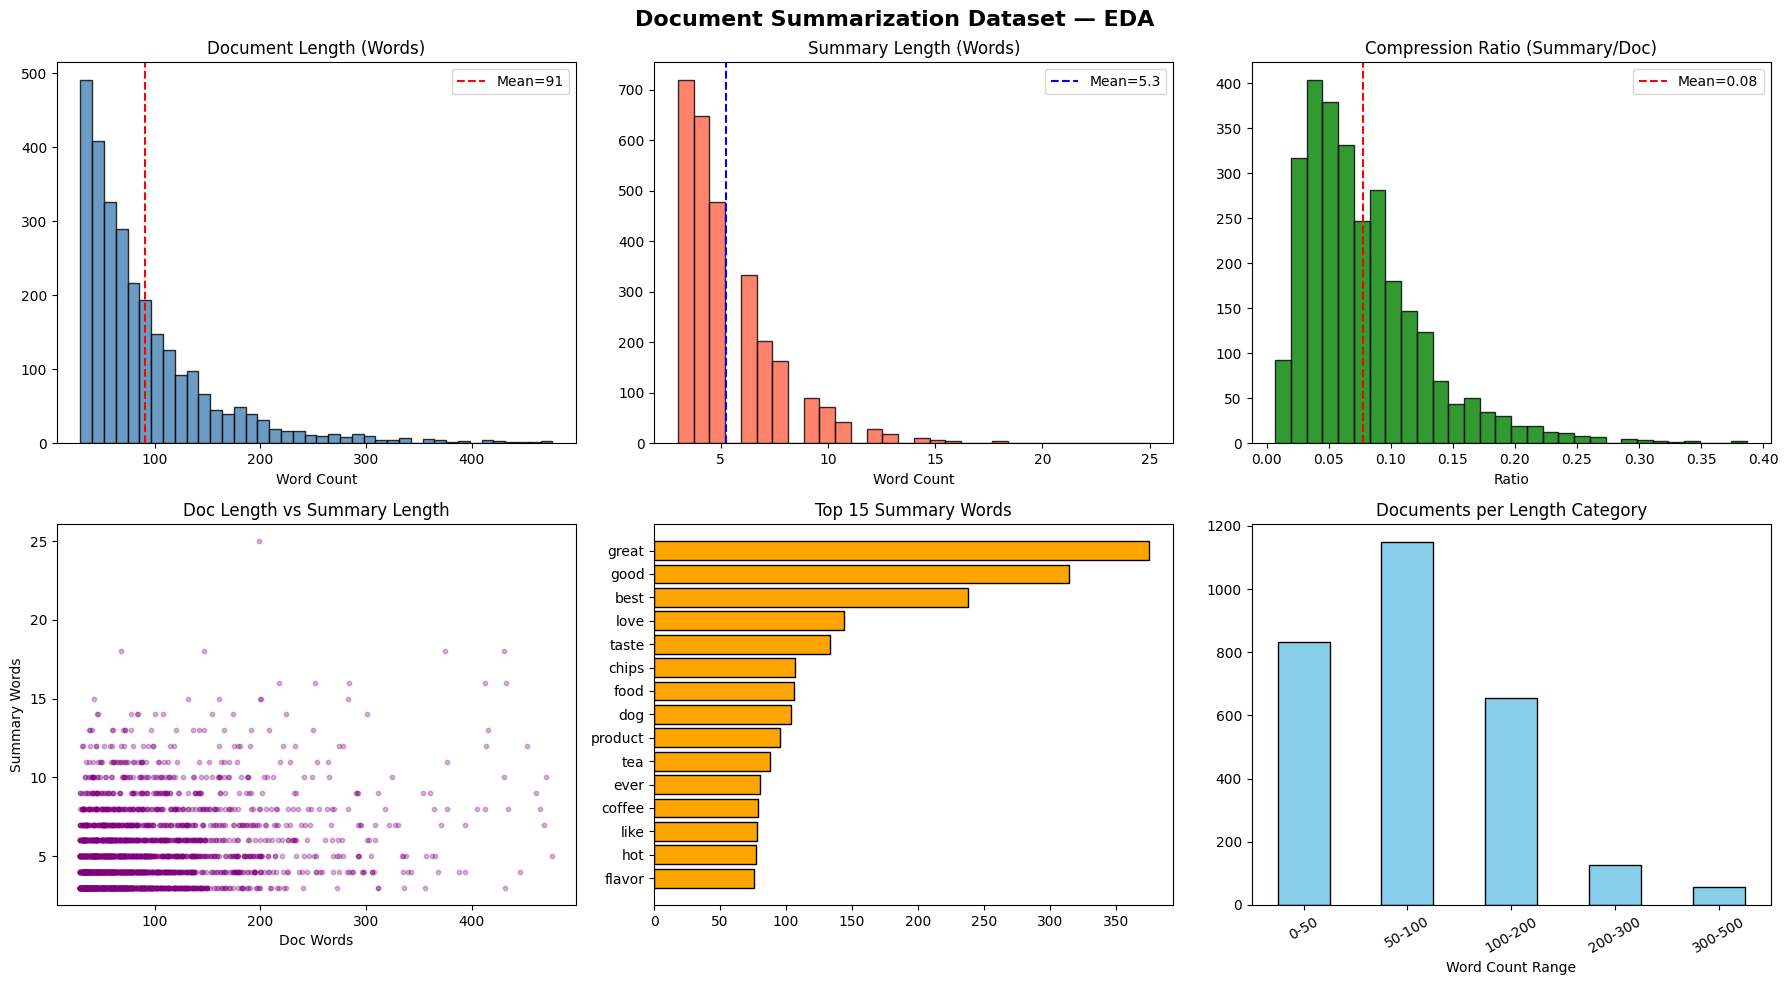

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Document Summarization Dataset — EDA',
             fontsize=16, fontweight='bold')

# 6a. Document length distribution
axes[0,0].hist(df['text_len'].clip(upper=500),
               bins=40, color='steelblue',
               edgecolor='black', alpha=0.8)
axes[0,0].axvline(df['text_len'].mean(), color='red',
                  linestyle='--',
                  label=f"Mean={df['text_len'].mean():.0f}")
axes[0,0].set_title('Document Length (Words)')
axes[0,0].set_xlabel('Word Count')
axes[0,0].legend()

# 6b. Summary length distribution
axes[0,1].hist(df['summary_len'].clip(upper=50),
               bins=30, color='tomato',
               edgecolor='black', alpha=0.8)
axes[0,1].axvline(df['summary_len'].mean(), color='blue',
                  linestyle='--',
                  label=f"Mean={df['summary_len'].mean():.1f}")
axes[0,1].set_title('Summary Length (Words)')
axes[0,1].set_xlabel('Word Count')
axes[0,1].legend()

# 6c. Compression ratio
df['compression'] = df['summary_len'] / df['text_len']
axes[0,2].hist(df['compression'], bins=30,
               color='green', edgecolor='black', alpha=0.8)
axes[0,2].axvline(df['compression'].mean(), color='red',
                  linestyle='--',
                  label=f"Mean={df['compression'].mean():.2f}")
axes[0,2].set_title('Compression Ratio (Summary/Doc)')
axes[0,2].set_xlabel('Ratio')
axes[0,2].legend()

# 6d. Scatter — doc vs summary length
axes[1,0].scatter(df['text_len'], df['summary_len'],
                  alpha=0.3, color='purple', s=10)
axes[1,0].set_title('Doc Length vs Summary Length')
axes[1,0].set_xlabel('Doc Words')
axes[1,0].set_ylabel('Summary Words')

# 6e. Top summary words (excluding stopwords)
all_sum_words = ' '.join(df['Summary'].tolist()).lower()
sum_tokens    = [w for w in word_tokenize(all_sum_words)
                 if w.isalpha() and w not in STOP_WORDS]
top_words     = Counter(sum_tokens).most_common(15)
axes[1,1].barh([w[0] for w in top_words],
               [w[1] for w in top_words],
               color='orange', edgecolor='black')
axes[1,1].set_title('Top 15 Summary Words')
axes[1,1].invert_yaxis()

# 6f. Doc length categories
bins   = [0,50,100,200,300,500]
labels = ['0-50','50-100','100-200','200-300','300-500']
df['len_cat'] = pd.cut(df['text_len'], bins=bins, labels=labels)
df['len_cat'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,2],
    color='skyblue', edgecolor='black')
axes[1,2].set_title('Documents per Length Category')
axes[1,2].set_xlabel('Word Count Range')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [7]:
def clean_text(text):
    """Basic text cleaning — preserve sentence structure."""
    if not isinstance(text, str):
        return ""
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Fix encoding issues
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text

def clean_for_nlp(text):
    """Aggressive cleaning for TF-IDF / Word2Vec."""
    text   = clean_text(text).lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

df['text_clean']  = df['Text'].apply(clean_text)
df['text_nlp']    = df['Text'].apply(clean_for_nlp)

print(" Text cleaning done!")
print("\nOriginal:")
print(df['Text'].iloc[0][:300])
print("\nCleaned:")
print(df['text_clean'].iloc[0][:300])
print("\nNLP cleaned:")
print(df['text_nlp'].iloc[0][:300])

 Text cleaning done!

Original:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than most.

NLP cleaned:
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


In [8]:
print("TOKENIZATION & SENTENCE SEGMENTATION DEMO")


sample_doc = df['text_clean'].iloc[0]

# Word tokenization
word_tokens = word_tokenize(sample_doc)
print(f"\n Word Tokens ({len(word_tokens)} total):")
print(f"   {word_tokens[:20]}")

# Sentence segmentation — NLTK
sent_tokens = sent_tokenize(sample_doc)
print(f"\n Sentence Segmentation — NLTK"
      f" ({len(sent_tokens)} sentences):")
for i, s in enumerate(sent_tokens[:4], 1):
    print(f"   S{i}: {s[:100]}")

# Sentence segmentation — spaCy
doc_spacy   = nlp_spacy(sample_doc[:1000])
spacy_sents = list(doc_spacy.sents)
print(f"\n Sentence Segmentation — spaCy"
      f" ({len(spacy_sents)} sentences):")
for i, s in enumerate(spacy_sents[:4], 1):
    print(f"   S{i}: {str(s)[:100]}")

# POS Tags
pos_tags = [(token.text, token.pos_)
            for token in doc_spacy
            if not token.is_stop][:15]
print(f"\n🔹 POS Tags (top 15):")
print(f"   {pos_tags}")

TOKENIZATION & SENTENCE SEGMENTATION DEMO

 Word Tokens (51 total):
   ['I', 'have', 'bought', 'several', 'of', 'the', 'Vitality', 'canned', 'dog', 'food', 'products', 'and', 'have', 'found', 'them', 'all', 'to', 'be', 'of', 'good']

 Sentence Segmentation — NLTK (3 sentences):
   S1: I have bought several of the Vitality canned dog food products and have found them all to be of good
   S2: The product looks more like a stew than a processed meat and it smells better.
   S3: My Labrador is finicky and she appreciates this product better than most.

 Sentence Segmentation — spaCy (3 sentences):
   S1: I have bought several of the Vitality canned dog food products and have found them all to be of good
   S2: The product looks more like a stew than a processed meat and it smells better.
   S3: My Labrador is finicky and she appreciates this product better than most.

🔹 POS Tags (top 15):
   [('bought', 'VERB'), ('Vitality', 'PROPN'), ('canned', 'VERB'), ('dog', 'NOUN'), ('food', 'NOUN'), 

In [9]:
def tfidf_sentence_scores(document):
    sentences = sent_tokenize(document)
    if len(sentences) < 2:
        return sentences, [1.0]

    # Clean sentences for TF-IDF
    clean_sents = [clean_for_nlp(s) for s in sentences]
    clean_sents = [s if s.strip() else 'empty'
                   for s in clean_sents]

    tfidf = TfidfVectorizer()
    try:
        tfidf_mat = tfidf.fit_transform(clean_sents)
    except:
        return sentences, [1.0] * len(sentences)

    # Score = sum of TF-IDF weights per sentence
    scores = np.array(tfidf_mat.sum(axis=1)).flatten()
    return sentences, scores

def tfidf_extractive_summary(document, num_sentences=3):
    """Extract top N sentences by TF-IDF score."""
    sentences, scores = tfidf_sentence_scores(document)
    if len(sentences) <= num_sentences:
        return ' '.join(sentences)

    # Get top sentence indices (maintain order)
    top_idx = np.argsort(scores)[-num_sentences:]
    top_idx = sorted(top_idx)
    summary = ' '.join([sentences[i] for i in top_idx])
    return summary

print(" TF-IDF Extractive Summarizer ready!")

# Demo
doc_sample  = df['text_clean'].iloc[0]
tfidf_summ  = tfidf_extractive_summary(doc_sample, num_sentences=2)
ref_summ    = df['Summary'].iloc[0]

print(f"\n Document (first 400 chars):")
print(f"   {doc_sample[:400]}")
print(f"\n TF-IDF Summary:")
print(f"   {tfidf_summ}")
print(f"\n Reference Summary:")
print(f"   {ref_summ}")

 TF-IDF Extractive Summarizer ready!

 Document (first 400 chars):
   I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than most.

 TF-IDF Summary:
   I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better.

 Reference Summary:
   Good Quality Dog Food


In [10]:
def textrank_summary(document, num_sentences=3,
                     damping=0.85, max_iter=100):
    sentences = sent_tokenize(document)
    if len(sentences) <= num_sentences:
        return ' '.join(sentences)

    # Clean for vectorization
    clean_sents = [clean_for_nlp(s) for s in sentences]
    clean_sents = [s if s.strip() else 'placeholder'
                   for s in clean_sents]

    # TF-IDF matrix
    try:
        tfidf = TfidfVectorizer()
        mat   = tfidf.fit_transform(clean_sents).toarray()
    except:
        return ' '.join(sentences[:num_sentences])

    # Cosine similarity matrix
    sim_mat = cosine_similarity(mat)
    np.fill_diagonal(sim_mat, 0)

    # Build graph & run PageRank
    graph  = nx.from_numpy_array(sim_mat)
    scores = nx.pagerank(graph,
                         alpha    = damping,
                         max_iter = max_iter)

    # Top sentences (preserve order)
    top_idx = sorted(
        sorted(scores, key=scores.get, reverse=True)[:num_sentences])
    summary = ' '.join([sentences[i] for i in top_idx])
    return summary

print(" TextRank Summarizer ready!")

# Demo
tr_summ = textrank_summary(doc_sample, num_sentences=2)
print(f"\n TextRank Summary:")
print(f"   {tr_summ}")

 TextRank Summarizer ready!

 TextRank Summary:
   The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than most.


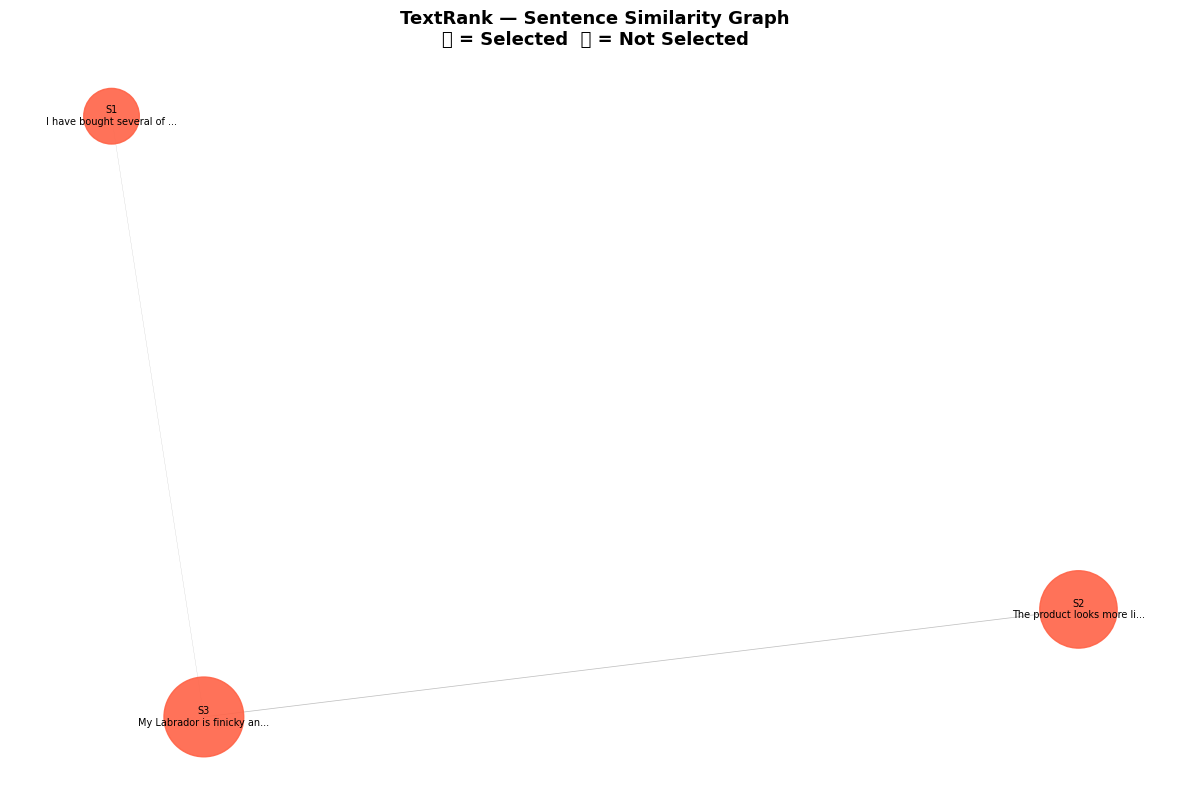

In [11]:
def plot_textrank_graph(document, num_sentences=3):
    sentences = sent_tokenize(document)[:8]  # limit for viz

    clean_sents = [clean_for_nlp(s) for s in sentences]
    clean_sents = [s if s.strip() else 'placeholder'
                   for s in clean_sents]

    try:
        tfidf   = TfidfVectorizer()
        mat     = tfidf.fit_transform(clean_sents).toarray()
        sim_mat = cosine_similarity(mat)
        np.fill_diagonal(sim_mat, 0)
    except:
        print("Cannot visualize — too few sentences")
        return

    graph  = nx.from_numpy_array(sim_mat)
    scores = nx.pagerank(graph, alpha=0.85)

    # Node sizes ∝ PageRank score
    node_sizes  = [scores[n] * 8000 for n in graph.nodes()]
    node_colors = ['tomato' if scores[n] >=
                   sorted(scores.values())[-num_sentences]
                   else 'steelblue'
                   for n in graph.nodes()]

    # Edge weights
    edges       = [(u, v) for u, v, d in graph.edges(data=True)
                   if d['weight'] > 0.05]
    edge_weights= [graph[u][v]['weight'] * 3
                   for u, v in edges]

    # Labels — short sentence preview
    labels = {i: f"S{i+1}\n{sentences[i][:25]}..."
              if len(sentences[i]) > 25
              else f"S{i+1}\n{sentences[i]}"
              for i in range(len(sentences))}

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(graph, seed=42)
    nx.draw_networkx_nodes(graph, pos,
                           node_size  = node_sizes,
                           node_color = node_colors,
                           alpha=0.9)
    nx.draw_networkx_edges(graph, pos,
                           edgelist = edges,
                           width    = edge_weights,
                           alpha    = 0.5,
                           edge_color='gray')
    nx.draw_networkx_labels(graph, pos, labels,
                            font_size=7)

    plt.title('TextRank — Sentence Similarity Graph\n'
              '🔴 = Selected  🔵 = Not Selected',
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_textrank_graph(doc_sample)

In [12]:
print(" Loading BERT for extractive summarization...")

st_model = SentenceTransformer('all-MiniLM-L6-v2')

def bert_extractive_summary(document, num_sentences=3):
    """
    BERT-based extractive summarization.
    Uses sentence embeddings + cosine similarity to document.
    """
    sentences = sent_tokenize(document)
    if len(sentences) <= num_sentences:
        return ' '.join(sentences)

    # Encode all sentences
    sent_embs  = st_model.encode(sentences,
                                  convert_to_numpy=True)

    # Document embedding = mean of sentence embeddings
    doc_emb    = sent_embs.mean(axis=0, keepdims=True)

    # Score = cosine similarity to document embedding
    scores     = cosine_similarity(sent_embs, doc_emb).flatten()

    # Top N sentences (preserve order)
    top_idx    = np.argsort(scores)[-num_sentences:]
    top_idx    = sorted(top_idx)
    summary    = ' '.join([sentences[i] for i in top_idx])
    return summary, scores, sentences

print(" BERT Extractive Summarizer ready!")

# Demo
result     = bert_extractive_summary(doc_sample, num_sentences=2)
bert_ex_summ, bert_scores, bert_sents = result

print(f"\n BERT Extractive Summary:")
print(f"   {bert_ex_summ}")
print(f"\n Sentence scores:")
for i, (s, sc) in enumerate(zip(bert_sents[:6], bert_scores[:6])):
    print(f"   S{i+1} [{sc:.4f}]: {s[:80]}...")

 Loading BERT for extractive summarization...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 BERT Extractive Summarizer ready!

 BERT Extractive Summary:
   I have bought several of the Vitality canned dog food products and have found them all to be of good quality. My Labrador is finicky and she appreciates this product better than most.

 Sentence scores:
   S1 [0.7949]: I have bought several of the Vitality canned dog food products and have found th...
   S2 [0.7303]: The product looks more like a stew than a processed meat and it smells better....
   S3 [0.7685]: My Labrador is finicky and she appreciates this product better than most....


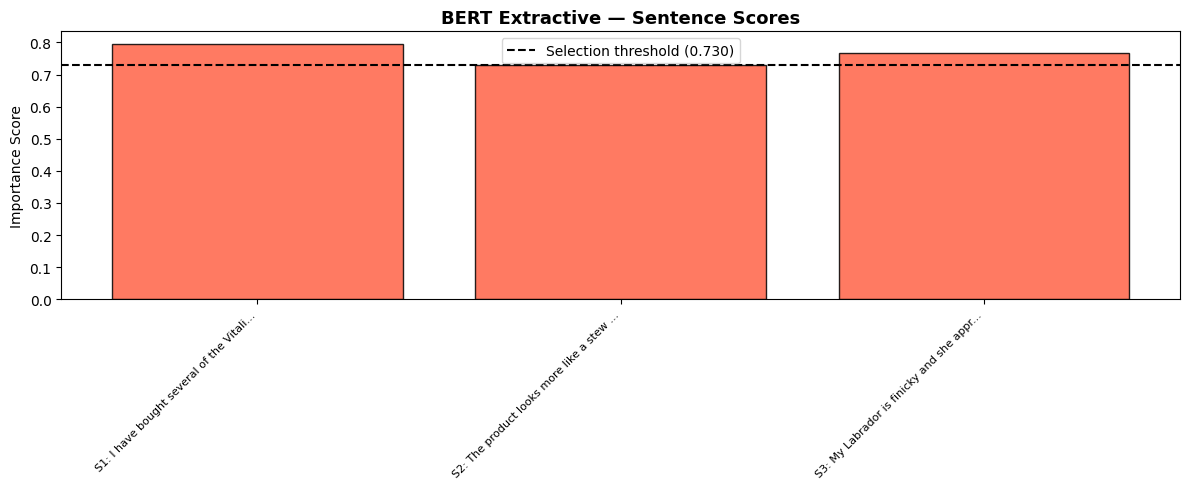

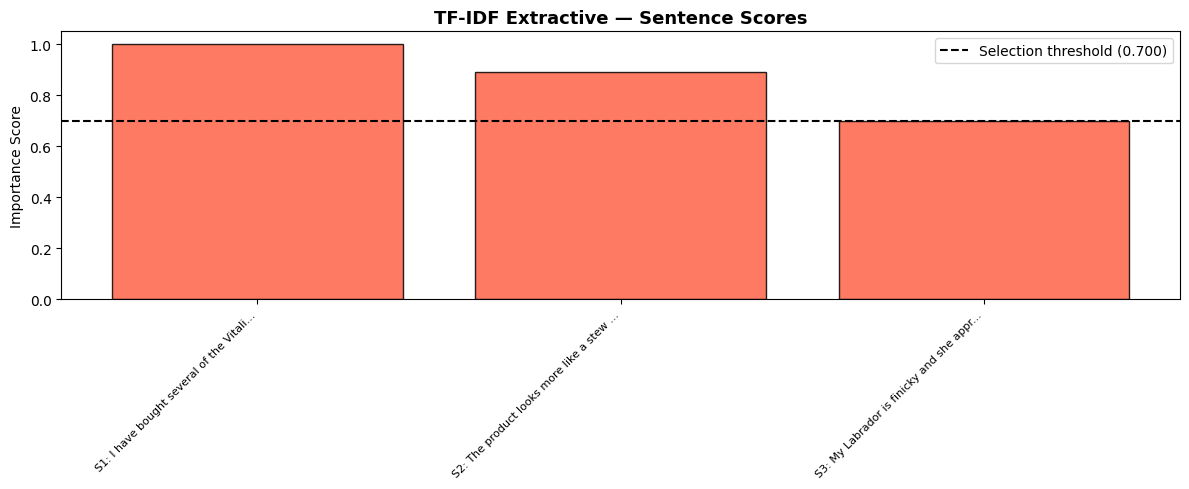

In [13]:
def plot_sentence_scores(document, method='bert', num_sentences=3):

    sentences = sent_tokenize(document)[:10]

    if method == 'bert':
        embs   = st_model.encode(sentences, convert_to_numpy=True)
        doc_e  = embs.mean(axis=0, keepdims=True)
        scores = cosine_similarity(embs, doc_e).flatten()
        title  = 'BERT Extractive — Sentence Scores'
        color  = 'steelblue'

    elif method == 'tfidf':
        _, scores = tfidf_sentence_scores(' '.join(sentences))
        scores    = scores[:len(sentences)]
        # normalize
        if scores.max() > 0:
            scores = scores / scores.max()
        title  = 'TF-IDF Extractive — Sentence Scores'
        color  = 'orange'

    threshold = sorted(scores)[-min(num_sentences, len(scores))]
    colors    = ['tomato' if s >= threshold
                 else color for s in scores]

    labels = [f"S{i+1}: {s[:35]}..."
              if len(s) > 35 else f"S{i+1}: {s}"
              for i, s in enumerate(sentences)]

    plt.figure(figsize=(12, 5))
    bars = plt.bar(range(len(sentences)), scores,
                   color=colors, edgecolor='black', alpha=0.85)
    plt.xticks(range(len(sentences)), labels,
               rotation=45, ha='right', fontsize=8)
    plt.ylabel('Importance Score')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axhline(threshold, color='black', linestyle='--',
                label=f'Selection threshold ({threshold:.3f})')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_sentence_scores(doc_sample, method='bert')
plot_sentence_scores(doc_sample, method='tfidf')

In [14]:
print(" Loading BART (facebook/bart-large-cnn)...")

BART_MODEL = 'facebook/bart-large-cnn'

bart_tokenizer = BartTokenizer.from_pretrained(BART_MODEL)
bart_model     = BartForConditionalGeneration.from_pretrained(
    BART_MODEL).to(device)

print(" BART loaded!")

def bart_summarize(text, max_input=1024,
                   max_new_tokens=120,
                   min_new_tokens=30,
                   num_beams=4,
                   length_penalty=2.0):
    """Abstractive summarization using BART."""
    text   = clean_text(text)
    inputs = bart_tokenizer(
        text,
        max_length    = max_input,
        truncation    = True,
        return_tensors= 'pt'
    ).to(device)

    with torch.no_grad():
        out = bart_model.generate(
            **inputs,
            max_new_tokens  = max_new_tokens,
            min_new_tokens  = min_new_tokens,
            num_beams       = num_beams,
            length_penalty  = length_penalty,
            early_stopping  = True,
            no_repeat_ngram_size = 3
        )

    summary = bart_tokenizer.decode(
        out[0], skip_special_tokens=True)
    return summary

# Demo
print("\n BART Summarization Demo...")
bart_summ = bart_summarize(doc_sample)
print(f"\n BART Summary:")
print(f"   {bart_summ}")
print(f"\n Reference:")
print(f"   {df['Summary'].iloc[0]}")

 Loading BART (facebook/bart-large-cnn)...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

 BART loaded!

 BART Summarization Demo...

 BART Summary:
   I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat. My Labrador is finicky and she appreciates this product better than most.

 Reference:
   Good Quality Dog Food


In [15]:
print(" Loading T5 (t5-small)...")

T5_MODEL = 't5-small'

t5_tokenizer = T5Tokenizer.from_pretrained(T5_MODEL)
t5_model     = T5ForConditionalGeneration.from_pretrained(
    T5_MODEL).to(device)

print(" T5 loaded!")

def t5_summarize(text, max_input=512,
                 max_new_tokens=100,
                 min_new_tokens=20,
                 num_beams=4):
    text   = "summarize: " + clean_text(text)
    inputs = t5_tokenizer(
        text,
        max_length    = max_input,
        truncation    = True,
        return_tensors= 'pt'
    ).to(device)

    with torch.no_grad():
        out = t5_model.generate(
            **inputs,
            max_new_tokens       = max_new_tokens,
            min_new_tokens       = min_new_tokens,
            num_beams            = num_beams,
            early_stopping       = True,
            no_repeat_ngram_size = 3
        )

    summary = t5_tokenizer.decode(
        out[0], skip_special_tokens=True)
    return summary

# Demo
print("\n T5 Summarization Demo...")
t5_summ = t5_summarize(doc_sample)
print(f"\n T5 Summary:")
print(f"   {t5_summ}")

 Loading T5 (t5-small)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

 T5 loaded!

 T5 Summarization Demo...

 T5 Summary:
   the product looks more like a stew than a processed meat and smells better. my Labrador is finicky and she appreciates this product better than most.


In [16]:
print(" Loading PEGASUS (google/pegasus-xsum)...")

PEGASUS_MODEL = 'google/pegasus-xsum'

peg_tokenizer = PegasusTokenizer.from_pretrained(PEGASUS_MODEL)
peg_model     = PegasusForConditionalGeneration.from_pretrained(
    PEGASUS_MODEL).to(device)

print(" PEGASUS loaded!")

def pegasus_summarize(text, max_input=512,
                      max_new_tokens=80,
                      min_new_tokens=15,
                      num_beams=4):
    text   = clean_text(text)
    inputs = peg_tokenizer(
        text,
        max_length    = max_input,
        truncation    = True,
        return_tensors= 'pt'
    ).to(device)

    with torch.no_grad():
        out = peg_model.generate(
            **inputs,
            max_new_tokens       = max_new_tokens,
            min_new_tokens       = min_new_tokens,
            num_beams            = num_beams,
            early_stopping       = True,
            no_repeat_ngram_size = 3
        )

    summary = peg_tokenizer.decode(
        out[0], skip_special_tokens=True)
    return summary

# Demo
print("\n PEGASUS Summarization Demo...")
peg_summ = pegasus_summarize(doc_sample)
print(f"\n PEGASUS Summary:")
print(f"   {peg_summ}")

 Loading PEGASUS (google/pegasus-xsum)...


tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.encoder.embed_positions.weight | MISSING | 
model.decoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

 PEGASUS loaded!

 PEGASUS Summarization Demo...

 PEGASUS Summary:
   I have been a dog owner for over 30 years and have never had a bad experience with any of my products.


In [17]:
print(" LONG DOCUMENT SUMMARIZATION")

def chunk_text(text, tokenizer, max_tokens=400, overlap=50):
    words  = text.split()
    chunks = []
    start  = 0
    while start < len(words):
        end   = min(start + max_tokens, len(words))
        chunk = ' '.join(words[start:end])
        chunks.append(chunk)
        if end == len(words):
            break
        start = end - overlap   # overlap for context
    return chunks

def summarize_long_doc(text, model_fn,
                       max_tokens=400, overlap=50,
                       final_max=100):
    text   = clean_text(text)
    words  = text.split()

    # If short enough → summarize directly
    if len(words) <= max_tokens:
        return model_fn(text)

    # Step 1: Chunk summaries
    chunks        = chunk_text(text, None, max_tokens, overlap)
    chunk_summaries = []
    for i, chunk in enumerate(chunks):
        s = model_fn(chunk)
        chunk_summaries.append(s)
        print(f"  Chunk {i+1}/{len(chunks)} summarized ✓")

    # Step 2: Final summary of summaries
    combined  = ' '.join(chunk_summaries)
    final_sum = model_fn(combined)
    return final_sum, chunk_summaries

# Create a long document by concatenating 3 reviews
long_doc = ' '.join(df['text_clean'].iloc[:5].tolist())
print(f"\nLong document words: {len(long_doc.split())}")

print("\n Long doc → BART hierarchical summarization:")
result_long = summarize_long_doc(
    long_doc, bart_summarize, max_tokens=400)

if isinstance(result_long, tuple):
    final_summ, chunk_summs = result_long
    print(f"\n Final Summary:")
    print(f"   {final_summ}")
    print(f"\n Chunk Summaries:")
    for i, cs in enumerate(chunk_summs, 1):
        print(f"   Chunk {i}: {cs[:100]}...")
else:
    print(f"   {result_long}")

 LONG DOCUMENT SUMMARIZATION

Long document words: 365

 Long doc → BART hierarchical summarization:
   This saltwater taffy had great flavors and was very soft and chewy. I served it at a beach-themed party and everyone loved it! The flavour of this hot sauce makes it one of a kind!


In [19]:
print(" ROUGE EVALUATION")

scorer = rouge_scorer.RougeScorer(
    ['rouge1','rouge2','rougeL'], use_stemmer=True)

def compute_rouge(hypothesis, reference):
    """Compute ROUGE scores."""
    scores = scorer.score(reference, hypothesis)
    return {
        'ROUGE-1 P' : round(scores['rouge1'].precision, 4),
        'ROUGE-1 R' : round(scores['rouge1'].recall,    4),
        'ROUGE-1 F' : round(scores['rouge1'].fmeasure,  4),
        'ROUGE-2 P' : round(scores['rouge2'].precision, 4),
        'ROUGE-2 R' : round(scores['rouge2'].recall,    4),
        'ROUGE-2 F' : round(scores['rouge2'].fmeasure,  4),
        'ROUGE-L P' : round(scores['rougeL'].precision, 4),
        'ROUGE-L R' : round(scores['rougeL'].recall,    4),
        'ROUGE-L F' : round(scores['rougeL'].fmeasure,  4),
    }

# Single doc evaluation demo
ref = df['Summary'].iloc[0]

print(f"\n Reference  : {ref}")
print(f" TF-IDF     : {tfidf_summ[:100]}")
print(f" TextRank   : {tr_summ[:100]}")
print(f" BERT Extr  : {bert_ex_summ[:100]}")
print(f" BART       : {bart_summ[:100]}")
print(f" T5         : {t5_summ[:100]}")
print(f" PEGASUS    : {peg_summ[:100]}")

methods = {
    'TF-IDF'    : tfidf_summ,
    'TextRank'  : tr_summ,
    'BERT Extr' : bert_ex_summ,
    'BART'      : bart_summ,
    'T5'        : t5_summ,
    'PEGASUS'   : peg_summ,
}

print("\n ROUGE Scores (single document):")

rouge_single = {}
for name, summ in methods.items():
    scores = compute_rouge(summ, ref)
    rouge_single[name] = scores

    r1 = scores['ROUGE-1 F']
    r2 = scores['ROUGE-2 F']
    rl = scores['ROUGE-L F']

    print(f"\n  {name}:")
    print(f"    ROUGE-1 F : {r1:.4f}")
    print(f"    ROUGE-2 F : {r2:.4f}")
    print(f"    ROUGE-L F : {rl:.4f}")

print("\n ROUGE Evaluation Done!")

 ROUGE EVALUATION

 Reference  : Good Quality Dog Food
 TF-IDF     : I have bought several of the Vitality canned dog food products and have found them all to be of good
 TextRank   : The product looks more like a stew than a processed meat and it smells better. My Labrador is finick
 BERT Extr  : I have bought several of the Vitality canned dog food products and have found them all to be of good
 BART       : I have bought several of the Vitality canned dog food products and have found them all to be of good
 T5         : the product looks more like a stew than a processed meat and smells better. my Labrador is finicky a
 PEGASUS    : I have been a dog owner for over 30 years and have never had a bad experience with any of my product

 ROUGE Scores (single document):

  TF-IDF:
    ROUGE-1 F : 0.2000
    ROUGE-2 F : 0.1053
    ROUGE-L F : 0.1000

  TextRank:
    ROUGE-1 F : 0.0000
    ROUGE-2 F : 0.0000
    ROUGE-L F : 0.0000

  BERT Extr:
    ROUGE-1 F : 0.2162
    ROUGE-2 F : 0.1143

In [20]:
print(" Batch ROUGE Evaluation (50 samples)...")

N_EVAL = 50
eval_df = df.head(N_EVAL).copy()

batch_results = {m: {'ROUGE-1 F':[], 'ROUGE-2 F':[], 'ROUGE-L F':[]}
                 for m in ['TF-IDF','TextRank','BERT Extr',
                            'BART','T5','PEGASUS']}

print(f"Evaluating {N_EVAL} documents...")

for idx, row in eval_df.iterrows():
    doc = row['text_clean']
    ref = str(row['Summary'])

    try:
        # Extractive
        t = tfidf_extractive_summary(doc, 2)
        r = compute_rouge(t, ref)
        batch_results['TF-IDF']['ROUGE-1 F'].append(r['ROUGE-1 F'])
        batch_results['TF-IDF']['ROUGE-2 F'].append(r['ROUGE-2 F'])
        batch_results['TF-IDF']['ROUGE-L F'].append(r['ROUGE-L F'])

        tr = textrank_summary(doc, 2)
        r  = compute_rouge(tr, ref)
        batch_results['TextRank']['ROUGE-1 F'].append(r['ROUGE-1 F'])
        batch_results['TextRank']['ROUGE-2 F'].append(r['ROUGE-2 F'])
        batch_results['TextRank']['ROUGE-L F'].append(r['ROUGE-L F'])

        be, _, _ = bert_extractive_summary(doc, 2)
        r = compute_rouge(be, ref)
        batch_results['BERT Extr']['ROUGE-1 F'].append(r['ROUGE-1 F'])
        batch_results['BERT Extr']['ROUGE-2 F'].append(r['ROUGE-2 F'])
        batch_results['BERT Extr']['ROUGE-L F'].append(r['ROUGE-L F'])

        # Abstractive
        bs = bart_summarize(doc)
        r  = compute_rouge(bs, ref)
        batch_results['BART']['ROUGE-1 F'].append(r['ROUGE-1 F'])
        batch_results['BART']['ROUGE-2 F'].append(r['ROUGE-2 F'])
        batch_results['BART']['ROUGE-L F'].append(r['ROUGE-L F'])

        ts = t5_summarize(doc)
        r  = compute_rouge(ts, ref)
        batch_results['T5']['ROUGE-1 F'].append(r['ROUGE-1 F'])
        batch_results['T5']['ROUGE-2 F'].append(r['ROUGE-2 F'])
        batch_results['T5']['ROUGE-L F'].append(r['ROUGE-L F'])

        ps = pegasus_summarize(doc)
        r  = compute_rouge(ps, ref)
        batch_results['PEGASUS']['ROUGE-1 F'].append(r['ROUGE-1 F'])
        batch_results['PEGASUS']['ROUGE-2 F'].append(r['ROUGE-2 F'])
        batch_results['PEGASUS']['ROUGE-L F'].append(r['ROUGE-L F'])

        if idx % 10 == 0:
            print(f"  ✓ {idx+1}/{N_EVAL} done")
    except Exception as e:
        continue

print(" Batch evaluation done!")

 Batch ROUGE Evaluation (50 samples)...
Evaluating 50 documents...
  ✓ 1/50 done
  ✓ 11/50 done
  ✓ 21/50 done
  ✓ 31/50 done
  ✓ 41/50 done
 Batch evaluation done!


In [21]:
rouge_avg = {}
for model, metrics in batch_results.items():
    rouge_avg[model] = {
        'ROUGE-1 F': np.mean(metrics['ROUGE-1 F']),
        'ROUGE-2 F': np.mean(metrics['ROUGE-2 F']),
        'ROUGE-L F': np.mean(metrics['ROUGE-L F']),
    }

rouge_df = pd.DataFrame(rouge_avg).T.sort_values(
    'ROUGE-1 F', ascending=False)

print("\n Average ROUGE Scores (50 docs):")

print(rouge_df.round(4).to_string())


 Average ROUGE Scores (50 docs):
           ROUGE-1 F  ROUGE-2 F  ROUGE-L F
PEGASUS       0.1282     0.0329     0.1202
T5            0.1204     0.0343     0.1093
TextRank      0.1180     0.0351     0.1048
BART          0.1154     0.0391     0.1038
BERT Extr     0.1120     0.0386     0.1000
TF-IDF        0.0974     0.0266     0.0832


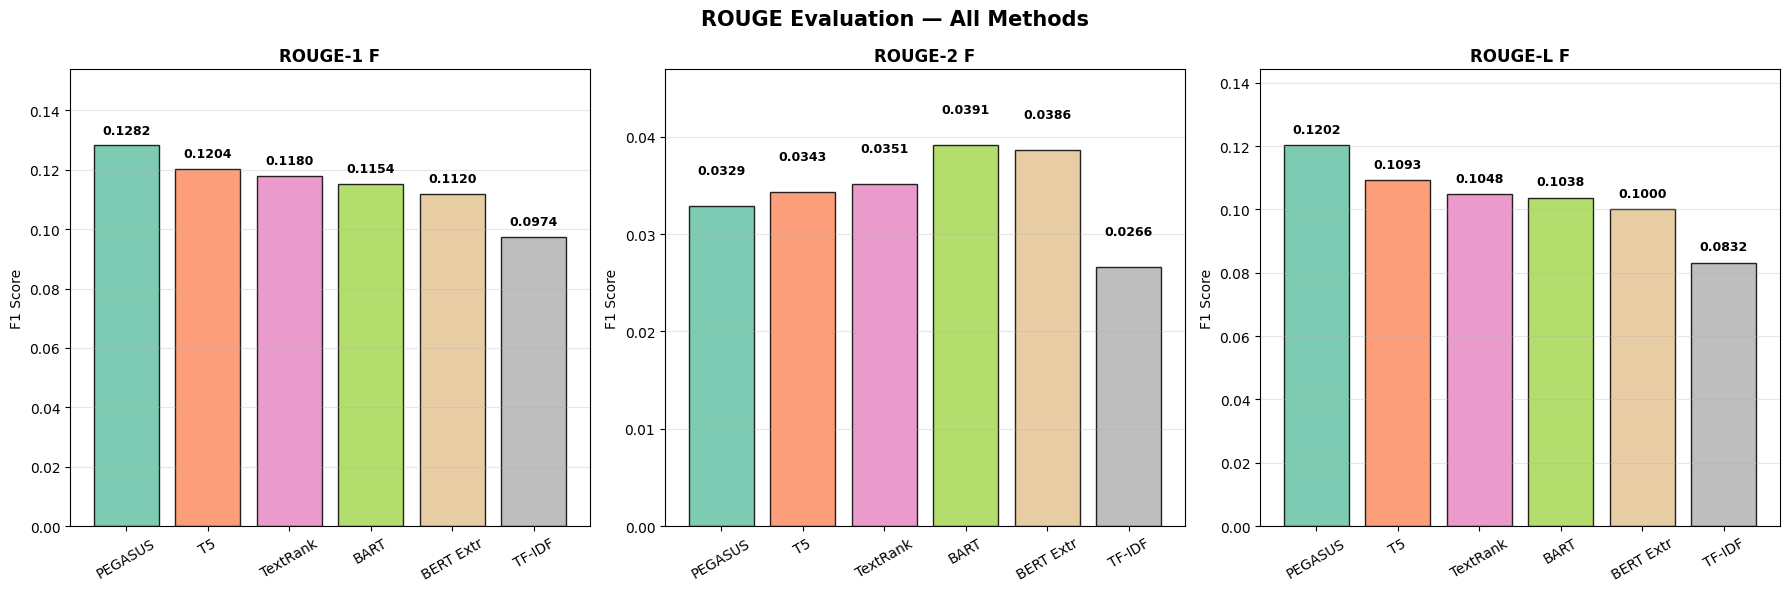

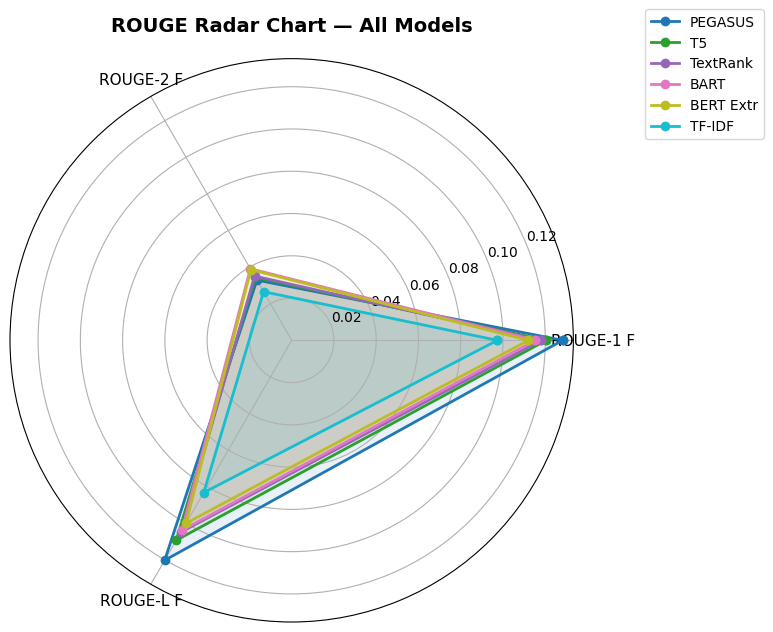

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROUGE Evaluation — All Methods',
             fontsize=15, fontweight='bold')

metrics = ['ROUGE-1 F','ROUGE-2 F','ROUGE-L F']
colors  = plt.cm.Set2(np.linspace(0, 1, len(rouge_df)))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(rouge_df.index,
                  rouge_df[metric],
                  color=colors,
                  edgecolor='black',
                  alpha=0.85)
    for bar, val in zip(bars, rouge_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.4f}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, rouge_df[metric].max() * 1.2)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Radar chart
fig_r, ax_r = plt.subplots(figsize=(8, 8),
                             subplot_kw=dict(polar=True))
n_metrics = len(metrics)
angles    = np.linspace(0, 2*np.pi, n_metrics,
                         endpoint=False).tolist()
angles   += angles[:1]

colors_r  = plt.cm.tab10(np.linspace(0, 1, len(rouge_df)))

for (model, row), color in zip(rouge_df.iterrows(), colors_r):
    vals  = row[metrics].tolist()
    vals += vals[:1]
    ax_r.plot(angles, vals, 'o-', lw=2,
              label=model, color=color)
    ax_r.fill(angles, vals, alpha=0.1, color=color)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(metrics, fontsize=11)
ax_r.set_title('ROUGE Radar Chart — All Models',
               fontsize=14, fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

 Summary Length Analysis...


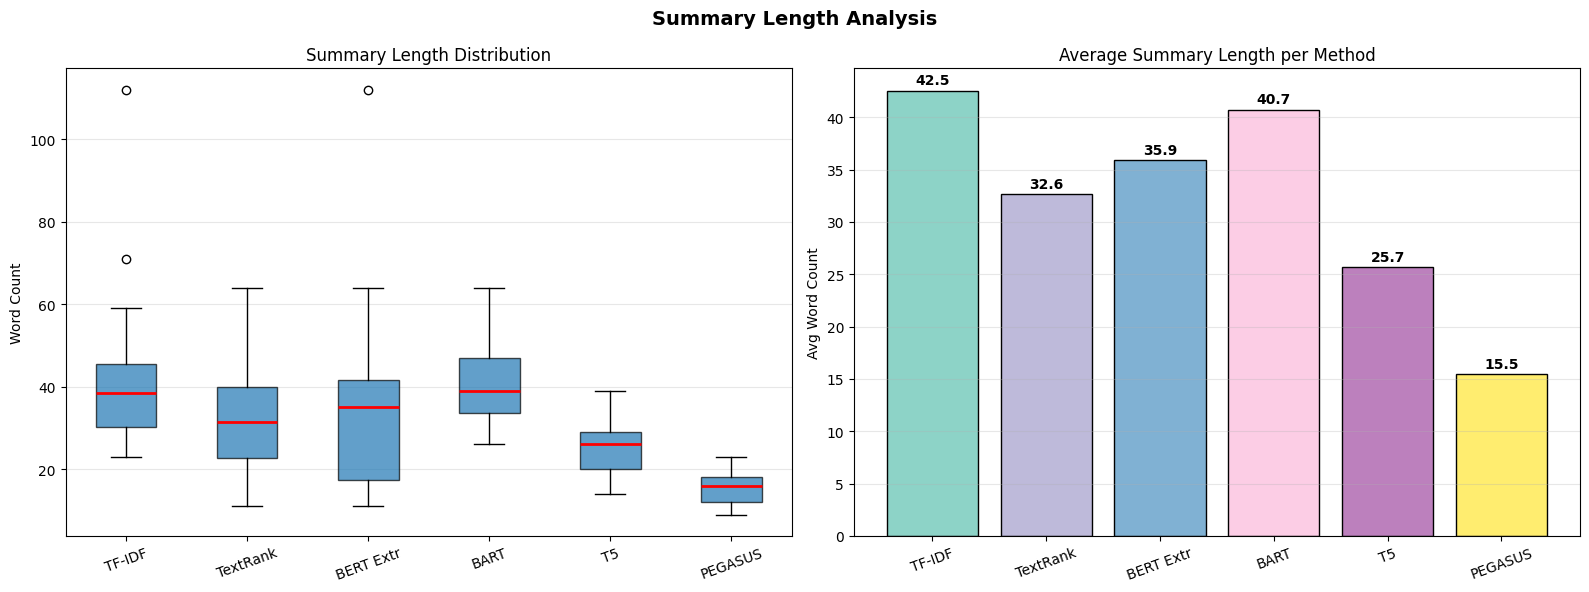

In [23]:
print(" Summary Length Analysis...")

# Generate summaries for 20 docs
N_LEN = 20
len_data = {m: [] for m in ['TF-IDF','TextRank',
                              'BERT Extr','BART','T5','PEGASUS']}

for idx in range(N_LEN):
    doc = df['text_clean'].iloc[idx]
    try:
        len_data['TF-IDF'].append(
            len(tfidf_extractive_summary(doc,2).split()))
        len_data['TextRank'].append(
            len(textrank_summary(doc,2).split()))
        r, _, _ = bert_extractive_summary(doc, 2)
        len_data['BERT Extr'].append(len(r.split()))
        len_data['BART'].append(
            len(bart_summarize(doc).split()))
        len_data['T5'].append(
            len(t5_summarize(doc).split()))
        len_data['PEGASUS'].append(
            len(pegasus_summarize(doc).split()))
    except:
        continue

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Summary Length Analysis',
             fontsize=14, fontweight='bold')

# Box plot
axes[0].boxplot(len_data.values(),
                labels    = len_data.keys(),
                patch_artist=True,
                boxprops  = dict(alpha=0.7),
                medianprops=dict(color='red', lw=2))
axes[0].set_ylabel('Word Count')
axes[0].set_title('Summary Length Distribution')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

# Mean lengths bar
means = {m: np.mean(v) for m, v in len_data.items()}
colors_l = plt.cm.Set3(np.linspace(0,1,len(means)))
bars = axes[1].bar(means.keys(), means.values(),
                   color=colors_l, edgecolor='black')
for bar, val in zip(bars, means.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}',
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Avg Word Count')
axes[1].set_title('Average Summary Length per Method')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
print(" SIDE-BY-SIDE SUMMARY COMPARISON")

COMPARE_N = 5

for i in range(COMPARE_N):
    doc = df['text_clean'].iloc[i]
    ref = df['Summary'].iloc[i]

    print(f"   Document #{i+1}")
    print(f"  Original ({len(doc.split())} words):")
    print(f"  {doc[:250]}...")
    print(f"\n   Reference Summary:")
    print(f"  {ref}")

    try:
        t  = tfidf_extractive_summary(doc, 2)
        tr = textrank_summary(doc, 2)
        be, _, _ = bert_extractive_summary(doc, 2)
        bs = bart_summarize(doc)
        ts = t5_summarize(doc)
        ps = pegasus_summarize(doc)

        print(f"\n   TF-IDF    : {t[:120]}")
        print(f"   TextRank  : {tr[:120]}")
        print(f"   BERT Extr : {be[:120]}")
        print(f"   BART      : {bs[:120]}")
        print(f"   T5        : {ts[:120]}")
        print(f"   PEGASUS   : {ps[:120]}")

        # ROUGE for this doc
        r1 = compute_rouge(bs, ref)['ROUGE-1 F']
        r2 = compute_rouge(ts, ref)['ROUGE-1 F']
        r3 = compute_rouge(ps, ref)['ROUGE-1 F']
        print(f"\n   ROUGE-1 F → BART:{r1:.3f}  "
              f"T5:{r2:.3f}  PEGASUS:{r3:.3f}")

    except Exception as e:
        print(f"  Error: {e}")

 SIDE-BY-SIDE SUMMARY COMPARISON
   Document #1
  Original (48 words):
  I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product bette...

   Reference Summary:
  Good Quality Dog Food

   TF-IDF    : I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The produc
   TextRank  : The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciate
   BERT Extr : I have bought several of the Vitality canned dog food products and have found them all to be of good quality. My Labrado
   BART      : I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The produc
   T5        : the product looks more like a stew than a processed meat and smell

In [25]:
print(" INTERACTIVE DOCUMENT SUMMARIZER")


def auto_summarize(text, method='bart',
                   num_sentences=3,
                   show_rouge=True,
                   reference=None):
    print(f"\n📄 Document ({len(text.split())} words):")
    print(f"   {text[:200]}...")

    summaries = {}

    if method in ['tfidf','all']:
        s = tfidf_extractive_summary(text, num_sentences)
        summaries['TF-IDF'] = s

    if method in ['textrank','all']:
        s = textrank_summary(text, num_sentences)
        summaries['TextRank'] = s

    if method in ['bert','all']:
        s, _, _ = bert_extractive_summary(text, num_sentences)
        summaries['BERT Extr'] = s

    if method in ['bart','all']:
        s = bart_summarize(text)
        summaries['BART'] = s

    if method in ['t5','all']:
        s = t5_summarize(text)
        summaries['T5'] = s

    if method in ['pegasus','all']:
        s = pegasus_summarize(text)
        summaries['PEGASUS'] = s

    print("\n Summaries:")
    for name, summ in summaries.items():
        print(f"\n  [{name}]")
        print(f"  {summ}")
        print(f"  ({len(summ.split())} words)")

    if show_rouge and reference:
        print(f"\n ROUGE vs Reference:")
        for name, summ in summaries.items():
            r = compute_rouge(summ, reference)
            print(f"  {name:<12} "
                  f"R1={r['ROUGE-1 F']:.3f}  "
                  f"R2={r['ROUGE-2 F']:.3f}  "
                  f"RL={r['ROUGE-L F']:.3f}")

    return summaries

# Test with custom text
custom_text = """
Artificial intelligence is rapidly transforming industries across the globe.
From healthcare to finance, AI-powered solutions are improving efficiency,
reducing costs, and enabling new capabilities. Machine learning algorithms
can now diagnose diseases with accuracy comparable to expert physicians.
Natural language processing enables computers to understand and generate
human language, powering applications like chatbots, translation services,
and document summarization. Computer vision systems can identify objects,
faces, and scenes in images and videos with remarkable precision.
The global AI market is expected to reach $1.8 trillion by 2030,
growing at a compound annual growth rate of over 35%.
Despite rapid progress, challenges remain including bias in AI systems,
lack of explainability, and concerns about job displacement.
Responsible AI development requires careful attention to ethics,
fairness, and transparency throughout the development lifecycle.
"""

custom_ref = "AI is transforming industries globally with applications in healthcare, finance, and NLP, with the market expected to reach $1.8 trillion by 2030 despite ethical challenges."

summaries = auto_summarize(
    custom_text,
    method    = 'all',
    reference = custom_ref
)

 INTERACTIVE DOCUMENT SUMMARIZER

📄 Document (128 words):
   
Artificial intelligence is rapidly transforming industries across the globe.
From healthcare to finance, AI-powered solutions are improving efficiency,
reducing costs, and enabling new capabilities. ...

 Summaries:

  [TF-IDF]
  From healthcare to finance, AI-powered solutions are improving efficiency,
reducing costs, and enabling new capabilities. Natural language processing enables computers to understand and generate
human language, powering applications like chatbots, translation services,
and document summarization. Despite rapid progress, challenges remain including bias in AI systems,
lack of explainability, and concerns about job displacement.
  (53 words)

  [TextRank]
  Natural language processing enables computers to understand and generate
human language, powering applications like chatbots, translation services,
and document summarization. Computer vision systems can identify objects,
faces, and scenes in image

In [26]:
print("FINAL ROUGE LEADERBOARD")


final_rouge = rouge_df.copy()
final_rouge.columns = ['ROUGE-1 F','ROUGE-2 F','ROUGE-L F']

print(final_rouge.round(4).to_string())


for metric in ['ROUGE-1 F','ROUGE-2 F','ROUGE-L F']:
    best = final_rouge[metric].idxmax()
    val  = final_rouge[metric].max()
    print(f"   Best {metric}: {best:<15} ({val:.4f})")



# Method summary
print("\n METHOD SUMMARY:")
summary_table = {
    'Method'    : ['TF-IDF','TextRank','BERT Extr',
                   'BART','T5','PEGASUS'],
    'Type'      : ['Extractive','Extractive','Extractive',
                   'Abstractive','Abstractive','Abstractive'],
    'Approach'  : ['Frequency scoring','Graph PageRank',
                   'Semantic similarity','Seq2Seq CNN',
                   'Text-to-Text','Gap sentence'],
    'Speed'     : ['⚡ Fast','⚡ Fast','🔶 Medium',
                   '🐢 Slow','🔶 Medium','🐢 Slow'],
    'Quality'   : ['⭐⭐','⭐⭐⭐','⭐⭐⭐',
                   '⭐⭐⭐⭐⭐','⭐⭐⭐⭐','⭐⭐⭐⭐⭐'],
}
print(pd.DataFrame(summary_table).to_string(index=False))
print("\n Document Summarization Project Complete!")

FINAL ROUGE LEADERBOARD
           ROUGE-1 F  ROUGE-2 F  ROUGE-L F
PEGASUS       0.1282     0.0329     0.1202
T5            0.1204     0.0343     0.1093
TextRank      0.1180     0.0351     0.1048
BART          0.1154     0.0391     0.1038
BERT Extr     0.1120     0.0386     0.1000
TF-IDF        0.0974     0.0266     0.0832
   Best ROUGE-1 F: PEGASUS         (0.1282)
   Best ROUGE-2 F: BART            (0.0391)
   Best ROUGE-L F: PEGASUS         (0.1202)

 METHOD SUMMARY:
   Method        Type            Approach    Speed Quality
   TF-IDF  Extractive   Frequency scoring   ⚡ Fast      ⭐⭐
 TextRank  Extractive      Graph PageRank   ⚡ Fast     ⭐⭐⭐
BERT Extr  Extractive Semantic similarity 🔶 Medium     ⭐⭐⭐
     BART Abstractive         Seq2Seq CNN   🐢 Slow   ⭐⭐⭐⭐⭐
       T5 Abstractive        Text-to-Text 🔶 Medium    ⭐⭐⭐⭐
  PEGASUS Abstractive        Gap sentence   🐢 Slow   ⭐⭐⭐⭐⭐

 Document Summarization Project Complete!
